In [1]:
# open pickle files of numpy data and plot examples. The numpy data is in 3D arrays of shape (timestep, x, y) where the value is the exposure rate as determined by delfic
import numpy as np
import matplotlib.pyplot as plt
import pickle

sourceDirectory = './delfic_test/'

#build a list of all the folders in the source directory
import os
folders = [f for f in os.listdir(sourceDirectory) if os.path.isdir(os.path.join(sourceDirectory, f))]

#the folder name contains the metadata for the data, the format is dynamic based off the following code
# self.run_name = f"Y{int(self.blast_yield)}H{int(self.burst_height)}"
# self.run_name += f"SS{int(self.surface_wind_speed)}DS{int(self.surface_wind_direction)}"
# self.run_name += f"SA{int(self.winds_aloft_max)}BA{int(self.boundary_alt)}"
# the run_name becomes the folder name

folder: Y100H0SS5DS345SA20BA6672 576
(24, 512, 512)


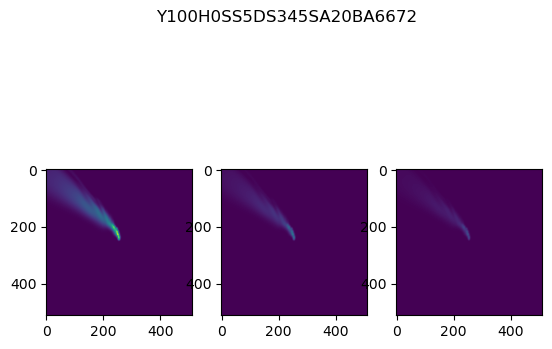

In [2]:
#use a random folder to open the pickle file and get the metadata
idx = np.random.randint(len(folders))
folder = folders[idx]
print(f"folder: {folder}", idx)
with open(sourceDirectory + folder + f'/{folder}.pkl', 'rb') as f:
    data = pickle.load(f)
    print(data.shape)

#plot the data for the first three timesteps
# use the same scale on the colorbar for all plots
#find the max and min of the data
maxVal = np.max(data)
minVal = np.min(data)
plt.figure()
plt.subplot(131)
plt.imshow(data[0], vmin=minVal, vmax=maxVal)
plt.subplot(132)
plt.imshow(data[1], vmin=minVal, vmax=maxVal)
plt.subplot(133)
plt.imshow(data[2], vmin=minVal, vmax=maxVal)
#provide a super label using the folder name
plt.suptitle(folder)
plt.show()

folder: Y10H0SS5DS29SA24BA4166, idx: 197


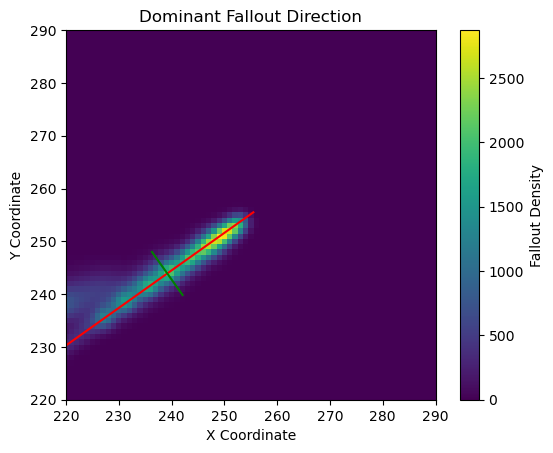

In [382]:
from math import trunc
from scipy.optimize import curve_fit

idx = np.random.randint(len(folders))
#idx = 405
folder = folders[idx]
print(f"folder: {folder}, idx: {idx}")
with open(sourceDirectory + folder + f'/{folder}.pkl', 'rb') as f:
    data = pickle.load(f)

#the blast is at the center of the image, look at the first timestep to determine the axis of fallout pattern
#flatten the data
data = data[0]

#reduce the data from 512x512 to 50x50, taking only the data from the center of the image
trunc_data = data[231:281, 231:281]

# Define a threshold for significant traffic
minThreshold = 0.1 * np.max(trunc_data)
maxThreshold = 0.9 * np.max(trunc_data)
# apply the min and max threshold
falloutIndices = np.nonzero((trunc_data > minThreshold) & (trunc_data < maxThreshold))
falloutX = np.array(falloutIndices[1])
falloutY = np.array(falloutIndices[0])
weights = trunc_data[falloutY, falloutX]  # Use traffic density as weights

# Calculate the center of the grid
centerX = (trunc_data.shape[1] - 1) / 2
centerY = (trunc_data.shape[0] - 1) / 2

# Convert to polar coordinates relative to the center
angles = np.arctan2(falloutY - centerY, falloutX - centerX)

# Compute the weighted average angle
falloutDir = np.arctan2(np.sum(np.sin(angles) * weights), np.sum(np.cos(angles) * weights))

# Create a line based on the average angle
line_length = max(trunc_data.shape)
x_fit = centerX + line_length * np.array([0, np.cos(falloutDir)])
y_fit = centerY + line_length * np.array([0, np.sin(falloutDir)])

#shift the line to the center of the image
x_fit += 231
y_fit += 231

# determine the angle of a line that is perpendicular to the fallout direction
perpendicular_angle = falloutDir + np.pi / 2

# determine a line that is 20 pixels long perpendicular to the fallout direction, 
# with the midpoint of the line at the center of the image
detectorFieldLength = 10
x_perpendicular = centerX + (detectorFieldLength/2) * np.array([np.cos(perpendicular_angle), -np.cos(perpendicular_angle)])
y_perpendicular = centerY + (detectorFieldLength/2) * np.array([np.sin(perpendicular_angle), -np.sin(perpendicular_angle)])

# translate the perpendicular line along the fallout direction by 20 units
detectorFieldDistance = 20
x_perpendicular += detectorFieldDistance * np.cos(falloutDir)
y_perpendicular += detectorFieldDistance * np.sin(falloutDir)

# Plotting
plt.imshow(data, origin='lower')
plt.colorbar(label='Fallout Density')
plt.plot(x_fit, y_fit, 'r-', label='Dominant Fallout Direction')
plt.plot(x_perpendicular + 231, y_perpendicular + 231, 'g-', label='Perpendicular to Dominant Direction')
plt.title('Dominant Fallout Direction')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.xlim(220, 290)
plt.ylim(220, 290)
plt.show()
